# Incendios de magnitud chile
### Objetivos: Relacionar la meteorologia con los incendios de magnitud  en chile. identificar patrones...

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------  9.4/9.5 MB 47.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 41.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 54.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 35.3 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 31.1 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- --

,ID,TEMPORADA,NOM_INCEN,CAUSA,SUPERFICIE,CODREG,CODPROV,CODCOM,REGION,COMUNA,PROVINCIA,FECHA_INI,FECHA_TER,SHAPE_Leng,SHAPE_Area,geometry
0,1,2013-2014,Santa Zenada-deuco,Otros incendios no clasificados,574.0,09,None,None,RegiÃ³n de La AraucanÃ­a,None,None,2014-01-05,NaT,22263.780564,5.739890e+06,"POLYGON ((173314.675 5808504.246, 173308.256 5..."
1,2,2013-2014,Fundo Monaco,Incendio Intencional,207.7,09,None,None,RegiÃ³n de La AraucanÃ­a,None,None,2013-12-25,NaT,11220.261899,2.076936e+06,"POLYGON ((176565.431 5807000.214, 176607.108 5..."
2,3,2013-2014,Toquihue,Incendio Intencional,891.3,09,None,None,RegiÃ³n de La AraucanÃ­a,None,None,2014-01-14,NaT,36282.411628,8.912981e+06,"POLYGON ((196002.738 5766858.892, 196051.874 5..."
3,28,2013-2014,Rumena,Incendios intencionales,3268.9,08,None,None,RegiÃ³n del BiobÃ­o,None,None,2013-12-21,NaT,43103.338004,3.268943e+07,"POLYGON ((90368.45 5869288.004, 90368.45 58692..."
4,4,2013-2014,Miraflores,ElaboraciÃ³n de carbÃ³n,1057.8,09,None,None,RegiÃ³n de La AraucanÃ­a,None,None,2014-01-13,NaT,33410.086989,1.057828e+07,"POLYGON ((167295.341 5797293.291, 167399.768 5..."


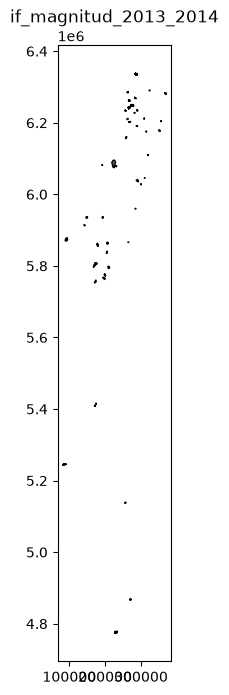

In [ ]:
# Si estás en un notebook y geopandas no está instalado, descomenta e instala:
%pip install geopandas
%pip install matplotlib

import geopandas as gpd
import matplotlib.pyplot as plt

# Usa raw string para evitar problemas con backslashes en Windows
shp_path = r"C:\Users\luisc\Documents\Github\analisis-geoespacial\incendios-magnitud-meteorologia\incendios\poligonos\if_magnitud_2013_2014\if_magnitud_2013_2014.shp"

# Cargar el shapefile
gdf = gpd.read_file(shp_path)

# Información básica
print("Filas:", len(gdf))
print("Columnas:", list(gdf.columns))
print("Tipo de geometría:", gdf.geometry.geom_type.unique())
print("CRS:", gdf.crs)

# Mostrar las primeras filas
display(gdf.head())

# Visualizar rápidamente
gdf.plot(figsize=(10, 8), edgecolor='k', cmap='tab20')
plt.title("if_magnitud_2013_2014")
plt.show()

## Auditoría y compilación de capas

Las capas no tienen exactamente el mismo esquema: las primeras temporadas usan nombres en mayúsculas, desde 2021 aparecen variaciones y 2023-2024 contiene campos adicionales. Se normalizan los campos comunes, se conservan los campos exclusivos y se añade `CAPA_ORIGEN`. Todas las geometrías se llevan a `EPSG:32719`; la capa de Isla de Pascua parte en `EPSG:32712`.

In [ ]:
from pathlib import Path
import pandas as pd

root = Path(r"C:\Users\luisc\Documents\Github\analisis-geoespacial\incendios-magnitud-meteorologia\incendios\poligonos")
output_path = root / "if_magnitud_compilado.gpkg"
target_crs = "EPSG:32719"

# Alias de los campos que representan la misma variable en distintas temporadas.
aliases = {
    "ID": "ID",
    "id": "ID",
    "TEMPORADA": "TEMPORADA",
    "temporada": "TEMPORADA",
    "NOM_INCEN": "NOM_INCEN",
    "nom_incen": "NOM_INCEN",
    "CAUSA": "CAUSA",
    "causa": "CAUSA",
    "SUPERFICIE": "SUPERFICIE",
    "superficie": "SUPERFICIE",
    "CODREG": "CODREG",
    "codreg": "CODREG",
    "CODPROV": "CODPROV",
    "codprov": "CODPROV",
    "CODCOM": "CODCOM",
    "codcom": "CODCOM",
    "REGION": "REGION",
    "region": "REGION",
    "COMUNA": "COMUNA",
    "comuna": "COMUNA",
    "PROVINCIA": "PROVINCIA",
    "provincia": "PROVINCIA",
    "FECHA_INI": "FECHA_INI",
    "fecha_ini": "FECHA_INI",
    "FH_INICIO": "FECHA_INI",
    "FECHA_TER": "FECHA_TER",
    "fecha_ter": "FECHA_TER",
    "FH_EXTINC": "FECHA_TER",
}

capas = []
for shp_path in sorted(root.glob("*/if_magnitud_*.shp")):
    capa = gpd.read_file(shp_path)
    capa = capa.to_crs(target_crs)
    capa = capa.rename(columns={
        nombre: aliases.get(nombre, nombre.upper())
        for nombre in capa.columns
        if nombre != capa.geometry.name
    })
    capa["CAPA_ORIGEN"] = shp_path.parent.name
    capa["TEMPORADA_ORIGEN"] = shp_path.parent.name.replace("if_magnitud_", "")
    capas.append(capa)

compilado = gpd.GeoDataFrame(pd.concat(capas, ignore_index=True, sort=False), crs=target_crs)

if output_path.exists():
    output_path.unlink()
compilado.to_file(output_path, layer="incendios_magnitud", driver="GPKG")

print(f"Capas compiladas: {len(capas)}")
print(f"Registros compilados: {len(compilado)}")
print(f"Campos finales: {len(compilado.columns)}")
print(f"CRS final: {compilado.crs}")
print(f"Geometrías inválidas: {(~compilado.geometry.is_valid).sum()}")
display(compilado.groupby("CAPA_ORIGEN").size().rename("registros").to_frame())
display(compilado.head())